# Ensemble Learning Techniques

This notebook demonstrates Ensemble Learning Techniques using a synthetic Weather dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Load and Preprocess Data

In [2]:
df = pd.read_csv('weather_dataset.csv')
display(df.head())

# Encode target
le = LabelEncoder()
df['Condition_Encoded'] = le.fit_transform(df['Condition'])

X = df[['Temperature_C', 'Humidity_%', 'Wind_Speed_kmh', 'Pressure_hPa']]
y = df['Condition_Encoded']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

,Temperature_C,Humidity_%,Wind_Speed_kmh,Pressure_hPa,Condition
0,29.967142,87.987109,9.598574,993.921924,Rainy
1,23.617357,78.492674,13.843851,1004.396150,Rainy
2,31.476885,61.192607,8.660641,1008.863945,Cloudy
3,40.230299,47.061264,12.536308,1031.876877,Sunny
4,22.658466,73.964466,-0.148917,1018.565531,Cloudy


## 3. Implement Random Forest Algorithm

In [3]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

## 4. Evaluate Model Performance

Random Forest Accuracy: 0.9950

Classification Report:
              precision    recall  f1-score   support

      Cloudy       1.00      0.99      1.00       106
       Rainy       0.93      1.00      0.96        13
       Sunny       1.00      1.00      1.00        81

    accuracy                           0.99       200
   macro avg       0.98      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



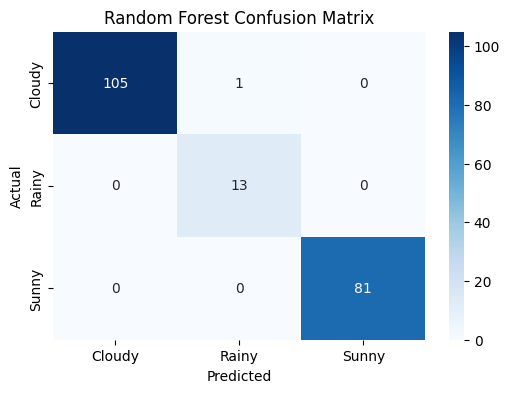

In [4]:
accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5. Compare with Other Algorithms

In [5]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
print(f'Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')

# Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')

Decision Tree Accuracy: 0.9950
Logistic Regression Accuracy: 0.7600


## 6. Save the Model

In [6]:
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
print('Models saved successfully!')

Models saved successfully!
